In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
       pass
print("done")
# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

done


In [2]:
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder 

In [15]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import time
import logging
from tqdm import tqdm
from sklearn.metrics import accuracy_score
from scipy import linalg
import tensorflow_io as tfio


In [16]:

# Configure logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

def configure_gpu():
    """Configure GPU settings for optimal performance"""
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        try:
            for gpu in gpus:
                tf.config.experimental.set_memory_growth(gpu, True)
                # Set memory limit
                tf.config.set_logical_device_configuration(
                    gpu,
                    [tf.config.LogicalDeviceConfiguration(memory_limit=1024)]
                )
            logical_gpus = tf.config.list_logical_devices('GPU')
            logger.info(f"{len(gpus)} Physical GPUs, {len(logical_gpus)} Logical GPUs")
        except RuntimeError as e:
            logger.error(f"GPU configuration error: {str(e)}")

In [2]:
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Preprocessing pipeline
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

# Load dataset
dataset_path = "/kaggle/input/mangoleaf-dataset/dataset"
data = datasets.ImageFolder(root=dataset_path, transform=transform)
dataloader = DataLoader(data, batch_size=64, shuffle=True)

# Check class names
print("Classes:", data.classes)


Classes: ['ANTHRACNOSE', 'BACTERIAL CRANKER', 'DIEBACK', 'GALL MILDGE', 'HEALTHY', 'MANGO SOOTY', 'SOOTY MOULD']


In [3]:
import torch.nn as nn

# Generator
class Generator(nn.Module):
    def __init__(self, nz=100):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(nz, 512, 4, 1, 0, bias=False),   # 1x1 → 4x4
            nn.BatchNorm2d(512),
            nn.ReLU(True),

            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),  # 4x4 → 8x8
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),  # 8x8 → 16x16
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),   # 16x16 → 32x32
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False),     # 32x32 → 64x64
            nn.Tanh()
        )

    def forward(self, input):
        return self.main(input)

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1, bias=False),      # 64x64 → 32x32
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, 4, 2, 1, bias=False),     # 32x32 → 16x16
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, 4, 2, 1, bias=False),    # 16x16 → 8x8
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256, 512, 4, 2, 1, bias=False),    # 8x8 → 4x4
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(512, 1, 4, 1, 0, bias=False),      # 4x4 → 1x1
            nn.Sigmoid()
        )

    def forward(self, input):
        output = self.main(input)
        return output.view(-1)  # now output shape is (batch_size,)


In [4]:
import torch

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [16]:
import torchvision

In [6]:
import torch
import torch.nn as nn

# Initialize device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Initialize models
netG = Generator().to(device)
netD = Discriminator().to(device)

# Loss and optimizers
criterion = nn.BCELoss()
optimizerD = torch.optim.Adam(netD.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizerG = torch.optim.Adam(netG.parameters(), lr=0.0002, betas=(0.5, 0.999))

# Fixed noise for visualization
nz = 100
fixed_noise = torch.randn(100, nz, 1, 1, device=device)

# Training loop
epochs = 5
for epoch in range(epochs):
    for i, (real_images, _) in enumerate(dataloader):
        batch_size = real_images.size(0)
        real_images = real_images.to(device)

        # Real and fake labels
        real_labels = torch.ones(batch_size, device=device)
        fake_labels = torch.zeros(batch_size, device=device)

        # Train Discriminator
        netD.zero_grad()
        output_real = netD(real_images).view(-1)
        loss_real = criterion(output_real, real_labels)

        noise = torch.randn(batch_size, nz, 1, 1, device=device)
        fake_images = netG(noise)
        output_fake = netD(fake_images.detach()).view(-1)
        loss_fake = criterion(output_fake, fake_labels)

        loss_D = loss_real + loss_fake
        loss_D.backward()
        optimizerD.step()

        # Train Generator
        netG.zero_grad()
        output = netD(fake_images).view(-1)
        loss_G = criterion(output, real_labels)
        loss_G.backward()
        optimizerG.step()

    print(f"Epoch [{epoch+1}/{epochs}]  Loss_D: {loss_D.item():.4f}  Loss_G: {loss_G.item():.4f}")


Using device: cpu
Epoch [1/5]  Loss_D: 0.0026  Loss_G: 15.9499
Epoch [2/5]  Loss_D: 0.0247  Loss_G: 13.0863
Epoch [3/5]  Loss_D: 0.2832  Loss_G: 12.1117
Epoch [4/5]  Loss_D: 2.2459  Loss_G: 3.4954
Epoch [5/5]  Loss_D: 0.5615  Loss_G: 3.3065


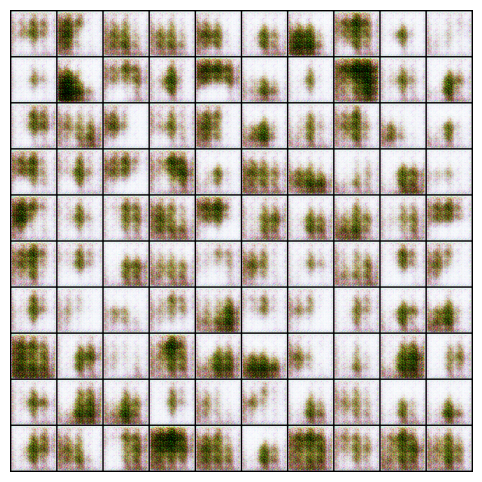

In [13]:
netG.eval()
with torch.no_grad():
    fake_imgs = netG(fixed_noise).cpu()
    show_images(fake_imgs, nrow=10)

In [7]:
import torch
import torch.nn as nn

# Initialize device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Initialize models
netG = Generator().to(device)
netD = Discriminator().to(device)

# Loss and optimizers
criterion = nn.BCELoss()
optimizerD = torch.optim.Adam(netD.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizerG = torch.optim.Adam(netG.parameters(), lr=0.0002, betas=(0.5, 0.999))

# Fixed noise for visualization
nz = 100
fixed_noise = torch.randn(100, nz, 1, 1, device=device)

# Training loop
epochs = 25
for epoch in range(epochs):
    for i, (real_images, _) in enumerate(dataloader):
        batch_size = real_images.size(0)
        real_images = real_images.to(device)

        # Real and fake labels
        real_labels = torch.ones(batch_size, device=device)
        fake_labels = torch.zeros(batch_size, device=device)

        # Train Discriminator
        netD.zero_grad()
        output_real = netD(real_images).view(-1)
        loss_real = criterion(output_real, real_labels)

        noise = torch.randn(batch_size, nz, 1, 1, device=device)
        fake_images = netG(noise)
        output_fake = netD(fake_images.detach()).view(-1)
        loss_fake = criterion(output_fake, fake_labels)

        loss_D = loss_real + loss_fake
        loss_D.backward()
        optimizerD.step()

        # Train Generator
        netG.zero_grad()
        output = netD(fake_images).view(-1)
        loss_G = criterion(output, real_labels)
        loss_G.backward()
        optimizerG.step()

    print(f"Epoch [{epoch+1}/{epochs}]  Loss_D: {loss_D.item():.4f}  Loss_G: {loss_G.item():.4f}")


Using device: cpu
Epoch [1/25]  Loss_D: 0.0589  Loss_G: 10.6734
Epoch [2/25]  Loss_D: 0.0013  Loss_G: 16.0062
Epoch [3/25]  Loss_D: 0.0421  Loss_G: 11.7526
Epoch [4/25]  Loss_D: 1.0592  Loss_G: 2.5996
Epoch [5/25]  Loss_D: 1.0317  Loss_G: 4.8196
Epoch [6/25]  Loss_D: 0.5656  Loss_G: 5.7158
Epoch [7/25]  Loss_D: 6.5415  Loss_G: 5.0874
Epoch [8/25]  Loss_D: 0.6563  Loss_G: 1.3667
Epoch [9/25]  Loss_D: 1.0062  Loss_G: 7.4410
Epoch [10/25]  Loss_D: 1.5377  Loss_G: 6.1193
Epoch [11/25]  Loss_D: 1.9421  Loss_G: 1.7909
Epoch [12/25]  Loss_D: 2.4858  Loss_G: 1.0474
Epoch [13/25]  Loss_D: 0.4111  Loss_G: 4.0681
Epoch [14/25]  Loss_D: 0.8509  Loss_G: 1.0699
Epoch [15/25]  Loss_D: 1.0381  Loss_G: 0.8413
Epoch [16/25]  Loss_D: 0.3754  Loss_G: 3.3019
Epoch [17/25]  Loss_D: 0.4157  Loss_G: 3.7299
Epoch [18/25]  Loss_D: 2.7348  Loss_G: 1.9861
Epoch [19/25]  Loss_D: 0.8429  Loss_G: 3.0853
Epoch [20/25]  Loss_D: 1.3697  Loss_G: 1.0922
Epoch [21/25]  Loss_D: 2.1622  Loss_G: 0.7548
Epoch [22/25]  Loss_D:

In [7]:


def show_images(images, nrow=10):
    grid = torchvision.utils.make_grid(images, nrow=nrow, normalize=True)
    plt.figure(figsize=(12, 6))
    plt.imshow(grid.permute(1, 2, 0))
    plt.axis("off")
    plt.show()



In [8]:
import torch
import numpy as np
from skimage.metrics import structural_similarity as ssim
from torchvision.models import Inception_V3_Weights, inception_v3
from scipy.linalg import sqrtm
import torch.nn.functional as F
from torchvision.utils import save_image
import os

# Configuration
NUM_CLASSES = 7
SAMPLES_PER_CLASS = 15
IMAGE_SIZE = 64
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Create output directories
os.makedirs("generated_images", exist_ok=True)
os.makedirs("evaluation", exist_ok=True)

# Initialize Inception v3 for FID
try:
    weights = Inception_V3_Weights.DEFAULT
    inception = inception_v3(weights=weights).to(DEVICE)
    inception.eval()
    print("Successfully loaded Inception v3 for FID calculation")
except Exception as e:
    print(f"Error loading Inception v3: {e}")
    inception = None

def calculate_ssim(real_images, fake_images):
    """Calculate SSIM between real and generated images"""
    ssim_values = []
    for real, fake in zip(real_images, fake_images):
        try:
            # Convert to numpy and normalize
            real_np = (real.permute(1, 2, 0).cpu().numpy() + 1) / 2  # [-1,1] -> [0,1]
            fake_np = (fake.permute(1, 2, 0).cpu().numpy() + 1) / 2
            
            # Calculate SSIM on grayscale
            ssim_val = ssim(
                np.mean(real_np, axis=2),
                np.mean(fake_np, axis=2),
                data_range=1.0,
                win_size=7
            )
            ssim_values.append(ssim_val)
        except Exception as e:
            print(f"SSIM calculation warning: {e}")
            continue
    
    return np.mean(ssim_values) if ssim_values else 0.0

def calculate_fid(real_images, fake_images):
    """Calculate Frechet Inception Distance"""
    if inception is None:
        print("Skipping FID - Inception model not available")
        return float('nan')
    
    def preprocess(images):
        return F.interpolate((images + 1) * 127.5, size=(299, 299), mode='bilinear')
    
    try:
        with torch.no_grad():
            real_features = inception(preprocess(real_images)).cpu().numpy()
            fake_features = inception(preprocess(fake_images)).cpu().numpy()
        
        mu_real, sigma_real = real_features.mean(axis=0), np.cov(real_features, rowvar=False)
        mu_fake, sigma_fake = fake_features.mean(axis=0), np.cov(fake_features, rowvar=False)
        
        covmean = sqrtm(sigma_real.dot(sigma_fake))
        if np.iscomplexobj(covmean):
            covmean = covmean.real
        
        return np.sum((mu_real - mu_fake)**2) + np.trace(sigma_real + sigma_fake - 2*covmean)
    except Exception as e:
        print(f"FID calculation error: {e}")
        return float('nan')

def generate_class_samples(netG):
    """Generate 15 samples per class"""
    netG.eval()
    samples = []
    
    for class_idx in range(NUM_CLASSES):
        try:
            noise = torch.randn(SAMPLES_PER_CLASS, 100, 1, 1, device=DEVICE)
            with torch.no_grad():
                fake = netG(noise).cpu()
            
            for i, img in enumerate(fake):
                save_image(
                    img,
                    f"generated_images/class_{class_idx}_sample_{i}.png",
                    normalize=True,
                    value_range=(-1, 1)  # Correct parameter name
                )
            samples.append(fake)
        except Exception as e:
            print(f"Generation error class {class_idx}: {e}")
    
    return torch.cat(samples) if samples else None

def evaluate_model(netG, dataloader):
    """Run full evaluation pipeline"""
    try:
        print("Generating samples...")
        fake_images = generate_class_samples(netG)
        if fake_images is None:
            raise RuntimeError("No images generated")
        
        # Get real images
        real_images = torch.cat([batch for batch, _ in dataloader])[:len(fake_images)].to(DEVICE)
        
        print("Calculating metrics...")
        ssim_score = calculate_ssim(real_images, fake_images)
        fid_score = calculate_fid(real_images, fake_images)
        
        print(f"\nEvaluation Results:")
        print(f"SSIM: {ssim_score:.4f} (0-1, higher better)")
        print(f"FID: {fid_score:.2f} (lower better)")
        
        with open("evaluation/metrics.txt", "w") as f:
            f.write(f"SSIM: {ssim_score:.4f}\nFID: {fid_score:.2f}\n")
        
        return ssim_score, fid_score
    except Exception as e:
        print(f"Evaluation failed: {e}")
        return float('nan'), float('nan')

# Example usage after training:
if __name__ == "__main__":
    # Assuming netG and dataloader are defined
    ssim, fid = evaluate_model(netG, dataloader)

Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth
100%|██████████| 104M/104M [00:00<00:00, 179MB/s] 


Successfully loaded Inception v3 for FID calculation
Generating samples...
Calculating metrics...

Evaluation Results:
SSIM: 0.1595 (0-1, higher better)
FID: 8094.66 (lower better)


In [12]:
import torchvision
import matplotlib.pyplot as plt

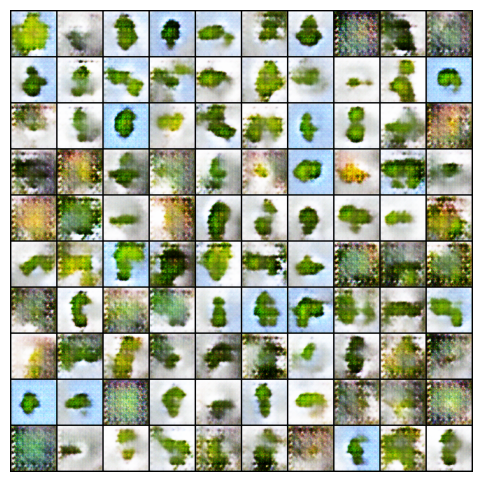

In [17]:
netG.eval()
with torch.no_grad():
    fake_imgs = netG(fixed_noise).cpu()
    show_images(fake_imgs, nrow=10)